In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Сортировка расчёской
Зависимость времени сортировки и количества перестановок от размера массива

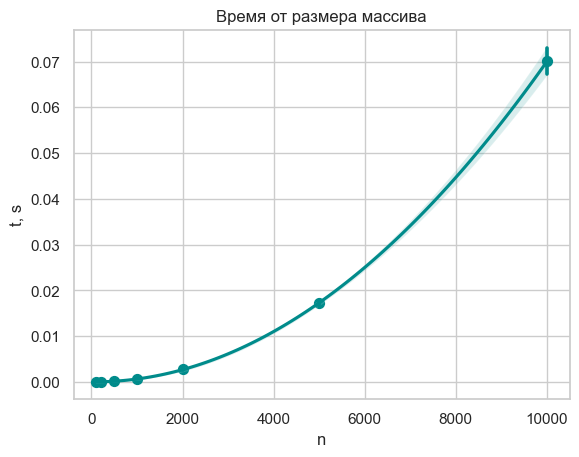

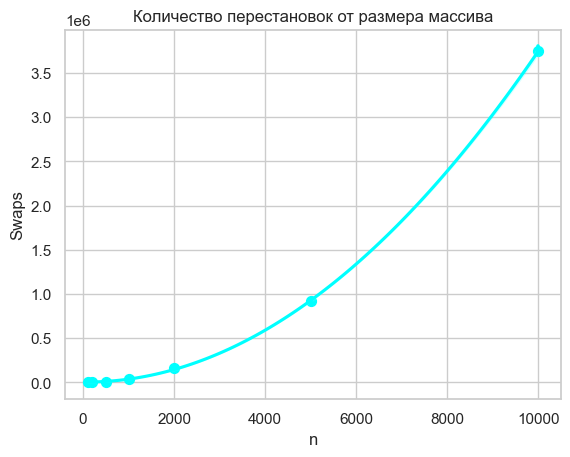

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("csv/brush_sort.csv")
df['t_s'] = df['t_ns'] / 1e9
# plt.figure(figsize=(10,6))
# plt.plot(df["n"], df["t_ns"])

plt.figure()
sns.set_theme(style="whitegrid")
sns.regplot(x = df["n"], y = df["t_s"], order=2, x_estimator=np.mean, ci = 95, color="darkcyan")

plt.xlabel("n")
plt.ylabel("t, s")
plt.title("Время от размера массива")
plt.savefig("./plots/brush_sort_times.png")
plt.show()

plt.figure()
# plt.plot(df["n"], df["swaps"])
sns.regplot(x = df["n"], y = df["swaps"], order=2, x_estimator=np.mean, ci = 95, color = "cyan")

plt.xlabel("n")
plt.ylabel("Swaps")
plt.title("Количество перестановок от размера массива")
plt.savefig("./plots/brush_sort_swaps.png")
plt.show()

## Сортировка Шелла
сравнение 3х различных шагов

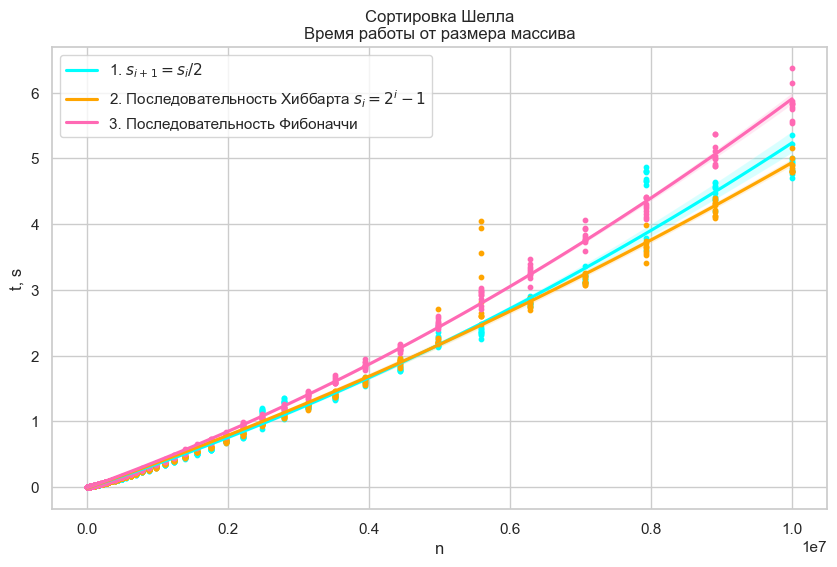

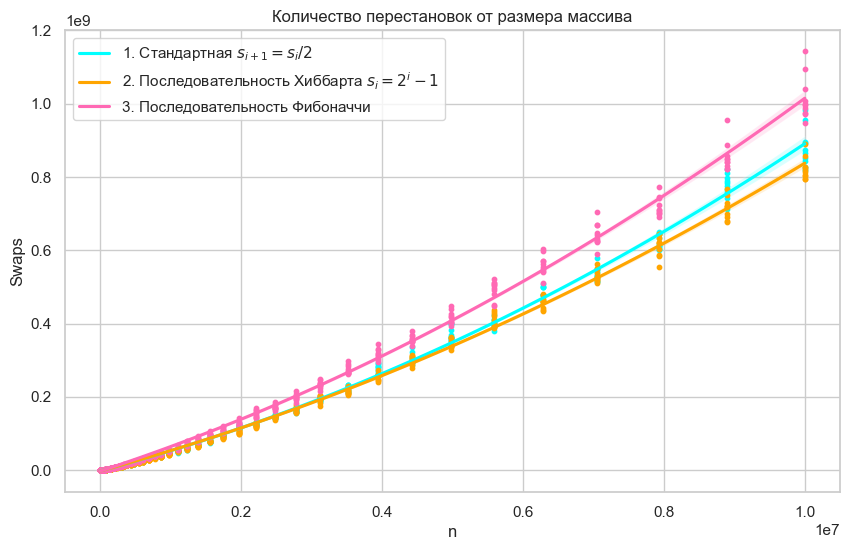

In [44]:
df_shell = pd.read_csv("csv/shell_sort.csv")
df_shell['t_s'] = df_shell['t_ns'] / 1e9

df_hibbard = pd.read_csv("csv/shell_hibbard_sort.csv")
df_hibbard['t_s'] = df_hibbard['t_ns'] / 1e9

df_fibonacci = pd.read_csv("csv/shell_fibonacci_sort.csv")
df_fibonacci['t_s'] = df_fibonacci['t_ns'] / 1e9

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.regplot(data=df_shell, x='n', y='t_s', order=2, x_estimator=np.mean, ci=95,
            label='1. $s_{i+1} = s_i/2$', color='cyan', scatter=False)
sns.regplot(data=df_hibbard, x='n', y='t_s', order=2, x_estimator=np.mean, ci=95,
            label='2. Последовательность Хиббарта $s_i = 2^i-1$', color='orange', scatter=False)
sns.regplot(data=df_fibonacci, x='n', y='t_s', order=2, x_estimator=np.mean, ci=95,
            label='3. Последовательность Фибоначчи', color='hotpink', scatter=False)

plt.scatter(df_shell['n'], df_shell['t_s'], color='cyan', s=10)
plt.scatter(df_hibbard['n'], df_hibbard['t_s'], color='orange', s=10)
plt.scatter(df_fibonacci['n'], df_fibonacci['t_s'], color='hotpink', s=10)

plt.xlabel("n")
plt.ylabel("t, s")
plt.title("Сортировка Шелла\nВремя работы от размера массива")
plt.legend()
plt.savefig("./plots/shell_sort_times.png")
plt.show()

plt.figure(figsize=(10, 6))

sns.regplot(data=df_shell, x='n', y='swaps', order=2, x_estimator=np.mean, ci=95,
            label='1. Стандартная $s_{i+1} = s_i/2$', color='cyan', scatter=False)
sns.regplot(data=df_hibbard, x='n', y='swaps', order=2, x_estimator=np.mean, ci=95,
            label='2. Последовательность Хиббарта $s_i = 2^i-1$', color='orange', scatter=False)
sns.regplot(data=df_fibonacci, x='n', y='swaps', order=2, x_estimator=np.mean, ci=95,
            label='3. Последовательность Фибоначчи', color='hotpink', scatter=False)

plt.scatter(df_shell['n'], df_shell['swaps'], color='cyan', s=10)
plt.scatter(df_hibbard['n'], df_hibbard['swaps'], color='orange', s=10)
plt.scatter(df_fibonacci['n'], df_fibonacci['swaps'], color='hotpink', s=10)

plt.xlabel("n")
plt.ylabel("Swaps")
plt.title("Количество перестановок от размера массива")
plt.legend()
plt.savefig("./plots/shell_sort_swaps.png")
plt.show()

### Логарифмическая линеаризацияи коэффициенты 

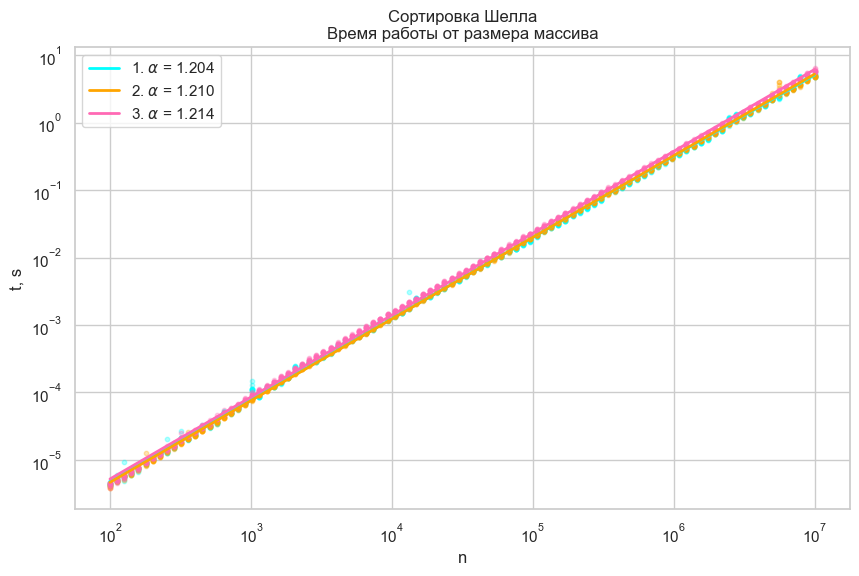

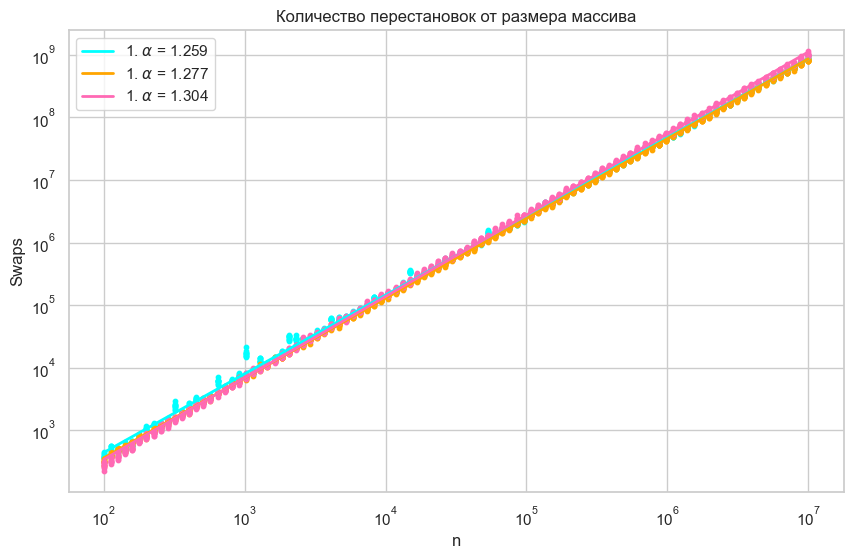

In [45]:
from scipy import stats

plt.figure(figsize=(10, 6))
i=1
for df, color in [(df_shell, 'cyan'), (df_hibbard, 'orange'), (df_fibonacci, 'hotpink')]:
    plt.scatter(df['n'], df['t_s'], color=color, alpha=0.3, s=10)
    slope, intercept, *_ = stats.linregress(np.log10(df['n']), np.log10(df['t_s']))
    x_fit = np.linspace(df['n'].min(), df['n'].max(), 100)
    plt.plot(x_fit, 10**(slope * np.log10(x_fit) + intercept), color=color, linewidth=2,
             label=f'{i}. $\\alpha$ = {slope:.3f}')
    i+=1
plt.xscale('log')
plt.yscale('log')
plt.xlabel("n")
plt.ylabel("t, s")
plt.title("Сортировка Шелла\nВремя работы от размера массива")
plt.savefig("./plots/shell_sort_times_log.png")
plt.legend()
plt.show()

i=1
plt.figure(figsize=(10, 6))
for df, color in [(df_shell, 'cyan'), (df_hibbard, 'orange'), (df_fibonacci, 'hotpink')]:
    plt.scatter(df['n'], df['swaps'], color=color, s=10)
    slope, intercept, *_ = stats.linregress(np.log10(df['n']), np.log10(df['swaps']))
    x_fit = np.linspace(df['n'].min(), df['n'].max(), 100)
    plt.plot(x_fit, 10**(slope * np.log10(x_fit) + intercept), color=color, linewidth=2,
             label=f'{i}. $\\alpha$ = {slope:.3f}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("n")
plt.ylabel("Swaps")
plt.title("Количество перестановок от размера массива")
plt.savefig("./plots/shell_sort_swaps_log.png")
plt.legend()
plt.show()

# Вспомогательно генерируем массивы

In [43]:
n_min = 100
n_max = 10_000_000
num_points = 100


log_min = np.log10(n_min)
log_max = np.log10(n_max)
ns = np.round(10 ** np.linspace(log_min, log_max, num_points)).astype(int)

ns = np.unique(ns)

# Формируем строку для вставки в C++ код
array_str = ', '.join(map(str, ns))
print(f'int ns[] = {{ {array_str} }};')

int ns[] = { 100, 112, 126, 142, 159, 179, 201, 226, 254, 285, 320, 359, 404, 453, 509, 572, 643, 722, 811, 911, 1024, 1150, 1292, 1451, 1630, 1831, 2057, 2310, 2595, 2915, 3275, 3678, 4132, 4642, 5214, 5857, 6579, 7391, 8302, 9326, 10476, 11768, 13219, 14850, 16681, 18738, 21049, 23645, 26561, 29836, 33516, 37649, 42292, 47508, 53367, 59948, 67342, 75646, 84975, 95455, 107227, 120450, 135305, 151991, 170735, 191791, 215443, 242013, 271859, 305386, 343047, 385353, 432876, 486260, 546228, 613591, 689261, 774264, 869749, 977010, 1097499, 1232847, 1384886, 1555676, 1747528, 1963041, 2205131, 2477076, 2782559, 3125716, 3511192, 3944206, 4430621, 4977024, 5590810, 6280291, 7054802, 7924829, 8902151, 10000000 };
